In [1]:
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [ ]:
# Replace these paths with the actual paths
SOURCE_DIR = "Discarded-Datasets/IRD-1500/data"      # Where your current images are
DEST_DIR = "Datasets/IRD-250/data"    # Where the 1-in-5 images will go

SOURCE_LABELS = "Discarded-Datasets/IRD-1500/labels" # Where your current labels are
DEST_LABELS = "Datasets/IRD-250/labels" 

# Create destination folders if they don't exist
os.makedirs(DEST_DIR, exist_ok=True)
if os.path.exists(SOURCE_LABELS):
    os.makedirs(DEST_LABELS, exist_ok=True)

# 1. Get all image files and sort them
valid_extensions = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
all_files = [f for f in os.listdir(SOURCE_DIR) if f.lower().endswith(valid_extensions)]

# Sorting guarantees the script reads them in alphabetical/numerical order,
# preserving the current sorting
all_files.sort() 

print(f"Found {len(all_files)} images. Extracting 1 out of every 5...")

# 2. Loop through and select the images
saved_count = 0

# enumerate() gives both an index (0, 1, 2...) and the file name
for index, filename in enumerate(all_files):
    
    # The modulo operator (%) gives the remainder of division.
    # index % 5 == 0 will only be True for index 0, 5, 10, 15, 20...
    if index % 5 == 0:
        
        # --- Copy the Image ---
        src_img_path = os.path.join(SOURCE_DIR, filename)
        dest_img_path = os.path.join(DEST_DIR, filename)
        shutil.copy2(src_img_path, dest_img_path)
        
        # --- Copy the Label (if it exists) ---
        # This replaces the .jpg extension with .txt
        txt_filename = os.path.splitext(filename)[0] + ".txt"
        src_txt_path = os.path.join(SOURCE_LABELS, txt_filename)
        
        # If the label exists in the source label folder, copy it too!
        if os.path.exists(src_txt_path):
            dest_txt_path = os.path.join(DEST_LABELS, txt_filename)
            shutil.copy2(src_txt_path, dest_txt_path)
            
        saved_count += 1

print(f"\nDone! Successfully copied {saved_count} images (and their labels) to the new folder.")

Found 1647 images. Extracting 1 out of every 5...

Done! Successfully copied 330 images (and their labels) to the new folder.



          DATASET BREAKDOWN              

Front-View-Turban
   - Helmet: 4
   - Pagdi: 291
   - No-Helmet: 108

Github-scraped-useful-600
   - Helmet: 808
   - Pagdi: 9
   - No-Helmet: 1679

IRD-250-v2
   - Helmet: 51
   - Pagdi: 5
   - No-Helmet: 71

Random-images-no-demographic-800
   - Helmet: 1620
   - Pagdi: 49
   - No-Helmet: 1084

Youtube-scraped-v3
   - Helmet: 64
   - Pagdi: 502
   - No-Helmet: 228

gender.multiclass-hijab-200
   - No-Helmet: 208

gender.multiclass-turban-120
   - Pagdi: 102

             TOTAL COUNTS                
Helmet: 2547
Pagdi: 958
No-Helmet: 3378


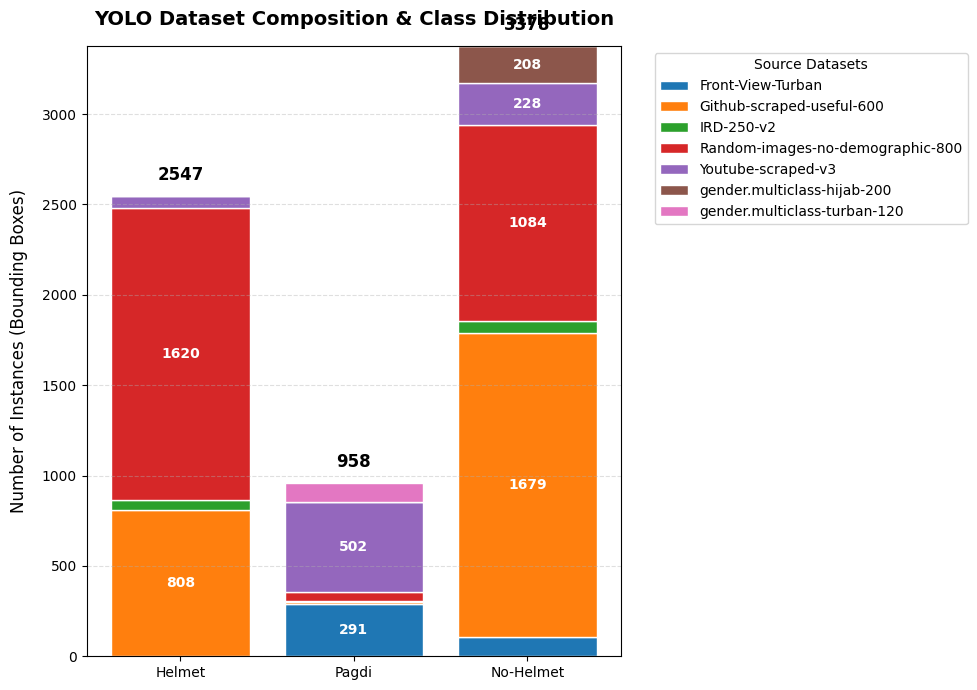

In [3]:
# --- 1. Configuration ---
DATASETS_ROOT = "New-Datasets" 
CLASS_MAP = {0: "Helmet", 1: "Pagdi", 2: "No-Helmet"}

dataset_stats = {}
total_counts = {0: 0, 1: 0, 2: 0}

# --- 2. Data Mining Loop ---
for dataset_name in sorted(os.listdir(DATASETS_ROOT)):
    dataset_path = os.path.join(DATASETS_ROOT, dataset_name)
    
    if not os.path.isdir(dataset_path):
        continue

    lbl_dir = os.path.join(dataset_path, "labels/train")
    if not os.path.exists(lbl_dir):
        continue

    # Initialize counters for this overall dataset folder
    dataset_stats[dataset_name] = {0: 0, 1: 0, 2: 0}

    for root, dirs, files in os.walk(lbl_dir):
        for txt_file in files:
            if not txt_file.endswith(".txt"):
                continue

            # Skip classes.txt if present to avoid reading header files
            if txt_file == "classes.txt":
                continue

            file_path = os.path.join(root, txt_file)
            with open(file_path, 'r') as f:
                for line in f:
                    try:
                        # Grab the first token (Class ID)
                        class_id = int(line.split()[0])
                        if class_id in dataset_stats[dataset_name]:
                            dataset_stats[dataset_name][class_id] += 1
                            total_counts[class_id] += 1
                    except (ValueError, IndexError):
                        pass 

# --- 3. Terminal Report ---
print("\n=========================================")
print("          DATASET BREAKDOWN              ")
print("=========================================")
for ds_name, counts in dataset_stats.items():
    print(f"\n{ds_name}")
    for cid, name in CLASS_MAP.items():
        if counts[cid] > 0:
            print(f"   - {name}: {counts[cid]}")

print("\n=========================================")
print("             TOTAL COUNTS                ")
print("=========================================")
for cid, name in CLASS_MAP.items():
    print(f"{name}: {total_counts[cid]}")

# --- 4. Drawing the Stacked Bar Chart ---
classes = [CLASS_MAP[0], CLASS_MAP[1], CLASS_MAP[2]]
fig, ax = plt.subplots(figsize=(10, 7))

bottoms = np.zeros(3)
colors = plt.cm.tab10.colors 

for idx, (ds_name, counts) in enumerate(dataset_stats.items()):
    values = [counts[0], counts[1], counts[2]]
    
    if sum(values) > 0:
        bars = ax.bar(classes, values, bottom=bottoms, label=ds_name, 
                      color=colors[idx % len(colors)], edgecolor='white')
        
        # Add labels inside blocks if > 5% of max bar height
        max_total = max(total_counts.values()) if total_counts.values() else 1
        for i, bar in enumerate(bars):
            if values[i] > (max_total * 0.05): 
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2, 
                        str(values[i]), ha='center', va='center', color='white', fontweight='bold')
                
        bottoms += values

# Grand Totals at top of stacks
max_total = max(total_counts.values()) if total_counts.values() else 1
for i, total in enumerate([total_counts[0], total_counts[1], total_counts[2]]):
    if total > 0:
        ax.text(i, total + (max_total * 0.02), str(total), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Styling
plt.title('YOLO Dataset Composition & Class Distribution', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Instances (Bounding Boxes)', fontsize=12, labelpad=10)
plt.legend(title='Source Datasets', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# --- 1. CONFIGURATION ---
# Input: The raw YouTube dataset
INPUT_IMAGES_DIR = "New-Datasets/Youtube-scraped/images/train"
INPUT_LABELS_DIR = "New-Datasets/Youtube-scraped/labels/train"

# Output: The new dataset folder exclusively for your cropped Pagdi patches
OUTPUT_IMAGES_DIR = "New-Datasets/Youtube-scraped-v2/images/train"
OUTPUT_LABELS_DIR = "New-Datasets/Youtube-scraped-v2/labels/train"

os.makedirs(OUTPUT_IMAGES_DIR, exist_ok=True)
os.makedirs(OUTPUT_LABELS_DIR, exist_ok=True)

TARGET_CLASS = 2  # We are only extracting patches for Pagdis

# PADDING MULTIPLIERS (Based on the box dimensions)
PAD_TOP = 0.25     # 1x the box height above
PAD_BOTTOM = 2.5  # 2.5x the box height below (Compensating for the 40% missing face + shoulders)
PAD_SIDE = 0.25    # 1.2x the box width on the left and right

print("Generating context-aware Pagdi patches...")
patch_count = 0

# --- 2. EXECUTION ---
for img_name in sorted(os.listdir(INPUT_IMAGES_DIR)):
    if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
        
    base_name = os.path.splitext(img_name)[0]
    txt_name = base_name + ".txt"
    
    img_path = os.path.join(INPUT_IMAGES_DIR, img_name)
    txt_path = os.path.join(INPUT_LABELS_DIR, txt_name)
    
    if not os.path.exists(txt_path):
        continue

    # Load the original full-context image
    image = cv2.imread(img_path)
    if image is None:
        continue
        
    img_h, img_w = image.shape[:2]
    
    with open(txt_path, 'r') as f:
        lines = f.readlines()
        
    # An image might have multiple Pagdis. We generate a separate patch for EACH one.
    pagdi_index = 0
    
    for line in lines:
        try:
            parts = line.split()
            if len(parts) < 5:
                continue
                
            class_id = int(parts[0])
            if class_id != TARGET_CLASS:
                continue # Ignore helmets and no-helmets for this patch generation
                
            # 1. Convert normalized YOLO coordinates to absolute pixels
            cx, cy, w, h = map(float, parts[1:5])
            
            box_px_w = w * img_w
            box_px_h = h * img_h
            box_px_cx = cx * img_w
            box_px_cy = cy * img_h
            
            box_x1 = box_px_cx - (box_px_w / 2.0)
            box_y1 = box_px_cy - (box_px_h / 2.0)
            box_x2 = box_px_cx + (box_px_w / 2.0)
            box_y2 = box_px_cy + (box_px_h / 2.0)
            
            # 2. Apply the Context Padding Logic
            crop_x1 = int(box_x1 - (box_px_w * PAD_SIDE))
            crop_y1 = int(box_y1 - (box_px_h * PAD_TOP))
            crop_x2 = int(box_x2 + (box_px_w * PAD_SIDE))
            crop_y2 = int(box_y2 + (box_px_h * PAD_BOTTOM)) # Heavy downward bias
            
            # 3. Clamp coordinates to ensure we don't try to crop outside the image
            crop_x1 = max(0, crop_x1)
            crop_y1 = max(0, crop_y1)
            crop_x2 = min(img_w, crop_x2)
            crop_y2 = min(img_h, crop_y2)
            
            # Prevent invalid zero-pixel crops if the box was sitting exactly on the frame edge
            if crop_x2 <= crop_x1 or crop_y2 <= crop_y1:
                continue
                
            # 4. Perform the physical image crop
            patch_img = image[crop_y1:crop_y2, crop_x1:crop_x2]
            
            # 5. Recalculate the YOLO coordinates for the NEW patch
            patch_h, patch_w = patch_img.shape[:2]
            
            # Find where the center of the box is relative to the new top-left corner of the crop
            new_px_cx = box_px_cx - crop_x1
            new_px_cy = box_px_cy - crop_y1
            
            # Normalize against the new patch dimensions
            new_norm_cx = new_px_cx / patch_w
            new_norm_cy = new_px_cy / patch_h
            new_norm_w = box_px_w / patch_w
            new_norm_h = box_px_h / patch_h
            
            # Clamp the normalized coordinates safely just in case of float rounding
            new_norm_cx = min(max(new_norm_cx, 0.0), 1.0)
            new_norm_cy = min(max(new_norm_cy, 0.0), 1.0)
            new_norm_w = min(max(new_norm_w, 0.0), 1.0)
            new_norm_h = min(max(new_norm_h, 0.0), 1.0)
            
            # 6. Save the new Patch and Label
            # Name format: original_video_frame_patch_0.jpg
            patch_base_name = f"{base_name}_patch_{pagdi_index}"
            
            cv2.imwrite(os.path.join(OUTPUT_IMAGES_DIR, patch_base_name + ".jpg"), patch_img)
            
            with open(os.path.join(OUTPUT_LABELS_DIR, patch_base_name + ".txt"), 'w') as out_f:
                out_f.write(f"{class_id} {new_norm_cx:.6f} {new_norm_cy:.6f} {new_norm_w:.6f} {new_norm_h:.6f}\n")
                
            pagdi_index += 1
            patch_count += 1
            
        except ValueError:
            continue

print(f"Success! Generated {patch_count} mathematically perfect texture patches.")

Generating context-aware Pagdi patches...
Success! Generated 185 mathematically perfect texture patches.


In [7]:
# --- Configuration ---
VIDEO_FOLDER = "Datasets/Youtube-scraped/youtube_scrape"    # Where your downloaded MP4s are
OUTPUT_FOLDER = "datasets/Youtube-scraped/data" # Where the images should go
SECONDS_PER_FRAME = 3              # Extract 1 frame every 5 seconds

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Starting video sampling...")

for video_name in os.listdir(VIDEO_FOLDER):
    if not video_name.endswith(".mp4"):
        continue

    video_path = os.path.join(VIDEO_FOLDER, video_name)
    cap = cv2.VideoCapture(video_path)
    
    # Get the Frames Per Second (fps) of the video
    fps = round(cap.get(cv2.CAP_PROP_FPS))
    frame_interval = fps * SECONDS_PER_FRAME
    
    frame_count = 0
    saved_count = 0
    
    print(f"Processing: {video_name} ({fps} fps)")

    while True:
        success, frame = cap.read()
        if not success:
            break # End of video
            
        # Only save if the current frame is a multiple of our interval
        if frame_count % frame_interval == 0:
            # Create a clean filename: video1_frame_0.jpg
            base_name = os.path.splitext(video_name)[0]
            out_filename = f"{base_name}_sec_{saved_count * SECONDS_PER_FRAME}.jpg"
            out_path = os.path.join(OUTPUT_FOLDER, out_filename)
            
            cv2.imwrite(out_path, frame)
            saved_count += 1
            
        frame_count += 1

    cap.release()
    print(f"  -> Extracted {saved_count} frames.")

print("\nSampling complete! Ready for Grounding DINO.")


Starting video sampling...
Processing: Driving_in_Chandigarh_4K_-_India.mp4 (30 fps)
  -> Extracted 568 frames.
Processing: Explore_Jalandhar_City_Walking_Tour_Streets_Local_Markets_Lifestyle_Jalandhar_Vlog_2025.mp4 (25 fps)
  -> Extracted 313 frames.
Processing: Verka_Bypass_Amritsar_Mela_2026_POV_Walk_Full_Crowd_Street_Vibes.mp4 (30 fps)
  -> Extracted 742 frames.
Processing: Ludhiana_s_Most_Spectacular_Streets_-_Mall_Road_-_Model_Town_-_Drive_4K.mp4 (60 fps)
  -> Extracted 602 frames.
Processing: Explore_Amritsar_in_2025_-_Golden_Temple_Local_Market_Vibrant_Streets_4K_UHD.mp4 (60 fps)
  -> Extracted 944 frames.
Processing: Chavinda_Devi_Mela_2026_POV_Walk_Full_Mela_Tour_Crowd_Shops_Vibes.mp4 (30 fps)
  -> Extracted 788 frames.
Processing: Model_Town_Daily_Vlog_4_Driving_Ludhiana.mp4 (60 fps)
  -> Extracted 355 frames.
Processing: MotoVlog_in_Amritsar_Golden_Temple_Ride_+_Punjabi_Roads_2025_amritsarlive.mp4 (30 fps)
  -> Extracted 178 frames.
Processing: Lawrence_Road_Amritsar_Night_

In [12]:
# --- 1. Configuration ---
DATASETS_ROOT = "Datasets"
TARGET_CLASSES = {0, 2}  # 0: Helmet, 2: No-Helmet

print("Scanning datasets to apply correct downward expansion...")
processed_files = 0
modified_boxes = 0

# --- 2. Iterate through all dataset folders ---
for dataset_name in sorted(os.listdir(DATASETS_ROOT)):
    dataset_path = os.path.join(DATASETS_ROOT, dataset_name)
    labels_dir = os.path.join(dataset_path, "labels")
    
    if not os.path.isdir(dataset_path) or not os.path.exists(labels_dir):
        continue
        
    print(f"Processing: {dataset_name}...")
    
    for label_file in os.listdir(labels_dir):
        if not label_file.endswith(".txt"):
            continue
            
        file_path = os.path.join(labels_dir, label_file)
        processed_files += 1
        
        with open(file_path, "r") as f:
            lines = f.readlines()
            
        new_lines = []
        file_modified = False
        
        for line in lines:
            try:
                parts = line.split()
                if len(parts) < 5:
                    new_lines.append(line)
                    continue
                    
                class_id = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                
                # --- 3. The Correct Geometry ---
                if class_id in TARGET_CLASSES:
                    # Width remains exactly as it is
                    new_w = w
                    
                    # Reconstruct the original 100% height
                    new_h = h / 0.6
                    
                    # Find the absolute top edge of the current cropped box
                    y_top = cy - (h / 2.0)
                    
                    # Calculate the intended bottom edge
                    y_bottom = y_top + new_h
                    
                    # Safety check: Cap the bottom edge at the frame boundary (1.0)
                    if y_bottom > 1.0:
                        y_bottom = 1.0
                        new_h = y_bottom - y_top
                    
                    # The new Y-center is precisely halfway between the locked top edge and the new bottom edge
                    new_cy = y_top + (new_h / 2.0)
                    
                    # Reconstruct the YOLO string cleanly
                    new_line = f"{class_id} {cx:.6f} {new_cy:.6f} {new_w:.6f} {new_h:.6f}\n"
                    new_lines.append(new_line)
                    modified_boxes += 1
                    file_modified = True
                else:
                    # Keep Pagdi (1) completely untouched
                    new_lines.append(line)
                    
            except ValueError:
                new_lines.append(line)
                
        # --- 4. Clean Overwrite ---
        if file_modified:
            with open(file_path, "w") as f:
                f.writelines(new_lines)

print(f"\nDone! Scanned {processed_files} files. Perfectly restored downward height for {modified_boxes} boxes without altering width.")

Scanning datasets to apply correct downward expansion...
Processing: Front view-turban-.yolov8-139...
Processing: Github-scraped-useful-600...
Processing: IRD-250...
Processing: Random-images-no-demographic-800...
Processing: Youtube-scraped...
Processing: gender.multiclass-hijab-200...
Processing: gender.multiclass-turban-120...

Done! Scanned 3104 files. Perfectly restored downward height for 6972 boxes without altering width.
